# Fast-FoundationStereo OAK 深度一致性评估

## tl;dr

- 两帧、`0.2–2.0 m` 主工作范围，像素加权结果：覆盖率 **99.941%**、MAE **4.510 cm**、RMSE **14.112 cm**、中位绝对误差 **4.931 mm**、δ1 **93.248%**。
- 中位误差远低于 MAE/RMSE，说明误差呈明显长尾；`3×3` 有效区腐蚀后 MAE 降至约 **2.03 cm**，主要异常集中于边界、遮挡和破碎参考区域。
- OAK `depth_mm` 是由同一双目输入生成的参考深度（伪 GT），本 notebook 衡量的是方法间一致性，不能单独证明绝对物理精度。


## Context & Methods

### Key Assumptions

- 预测深度来自已经保存的 `depth_meter.npy`，尺寸为 `400×640`、单位为米。
- OAK `depth_mm` 和 `valid_mask` 从 `800×1280` 使用 `cv2.INTER_NEAREST` 缩放到预测尺寸；深度数值只除以 `1000`，不会随图像缩放改变。
- 主工作范围定义为 `valid_mask > 0` 且 `0.2 ≤ reference ≤ 2.0 m`。
- 保存的无效预测为 `0 m`，主指标保留这些像素并计为失败；交集指标只作为辅助检查。
- `Bias = mean(prediction - reference)`；δk 使用 `max(pred/reference, reference/pred) < 1.25^k`。


In [1]:
from pathlib import Path
import importlib.util
import pandas as pd
from IPython.display import Image, display

run_dir = Path.cwd()
if (run_dir / 'depth_evaluation_analysis.py').is_file():
    report_dir = run_dir
    project_root = report_dir.parents[1]
else:
    project_root = run_dir
    report_dir = project_root / 'output/depth_evaluation_report'
analysis_path = report_dir / 'depth_evaluation_analysis.py'
spec = importlib.util.spec_from_file_location('depth_evaluation_analysis', analysis_path)
analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(analysis)
print('Analysis module:', analysis_path)


Analysis module: E:\stereo\Fast-FoundationStereo-master\output\depth_evaluation_report\depth_evaluation_analysis.py


## Data

In [2]:
loaded_cases = [analysis.load_case(case) for case in analysis.CASES]
data_rows = []
for case in loaded_cases:
    data_rows.append({
        'case': case['label'],
        'prediction_shape': str(case['pred'].shape),
        'reference_valid_pixels': int(case['reference_valid'].sum()),
        'work_range_pixels': int(case['work_mask'].sum()),
        'prediction_valid_pixels': int(case['prediction_valid'].sum()),
    })
pd.DataFrame(data_rows)


,case,prediction_shape,reference_valid_pixels,work_range_pixels,prediction_valid_pixels
0,Test 170600 / 00000032,"(400, 640)",155645,154645,241943
1,Train 172516 / 00000034,"(400, 640)",159498,157355,241823


## Results

In [3]:
results, chart_data = analysis.build_quantitative_results(loaded_cases)
summary = pd.DataFrame(chart_data['summary'])
summary


,scope,coverage,mae_cm,rmse_cm,median_ae_mm,abs_rel,delta1,over_10cm,bias_cm,eligible_pixels
0,0.2-2.0 m aggregate,0.99941,4.509929,14.112019,4.930526,0.073629,0.932484,0.089045,2.698761,312000


In [4]:
frame_metrics = pd.DataFrame(chart_data['frames'])
frame_metrics[['frame', 'eligible_pixels', 'coverage', 'mae_cm', 'rmse_cm', 'median_ae_mm', 'abs_rel', 'delta1', 'over_10cm', 'bias_cm']]


,frame,eligible_pixels,coverage,mae_cm,rmse_cm,median_ae_mm,abs_rel,delta1,over_10cm,bias_cm
0,00000032,154645,0.999243,4.119602,12.853641,5.562961,0.066477,0.941569,0.074965,2.102831
1,00000034,157355,0.999574,4.893535,15.247874,4.397094,0.080658,0.923555,0.102882,3.284427


In [5]:
depth_band_metrics = pd.DataFrame(chart_data['depth_bands'])
depth_band_metrics[['depth_band', 'eligible_pixels', 'coverage', 'mae_cm', 'rmse_cm', 'median_ae_mm', 'delta1', 'bias_cm']]


,depth_band,eligible_pixels,coverage,mae_cm,rmse_cm,median_ae_mm,delta1,bias_cm
0,0.2-0.5 m,1496,1.000000,23.385366,26.950161,241.550520,0.170455,-5.563959
1,0.5-1.0 m,296700,0.999484,4.158637,12.772260,4.641116,0.937297,3.268333
2,1.0-2.0 m,13804,0.997754,10.014907,30.268634,13.154924,0.911620,-8.648026
3,>2.0 m,3143,0.850780,735.971001,1208.473816,4234.808505,0.000000,-735.971001


### Qualitative evidence

所有深度图共享 `0.2–2.0 m` 色标（近红远蓝），绝对误差图在 `0.2 m` 截断。灰色表示没有参与主指标的区域。


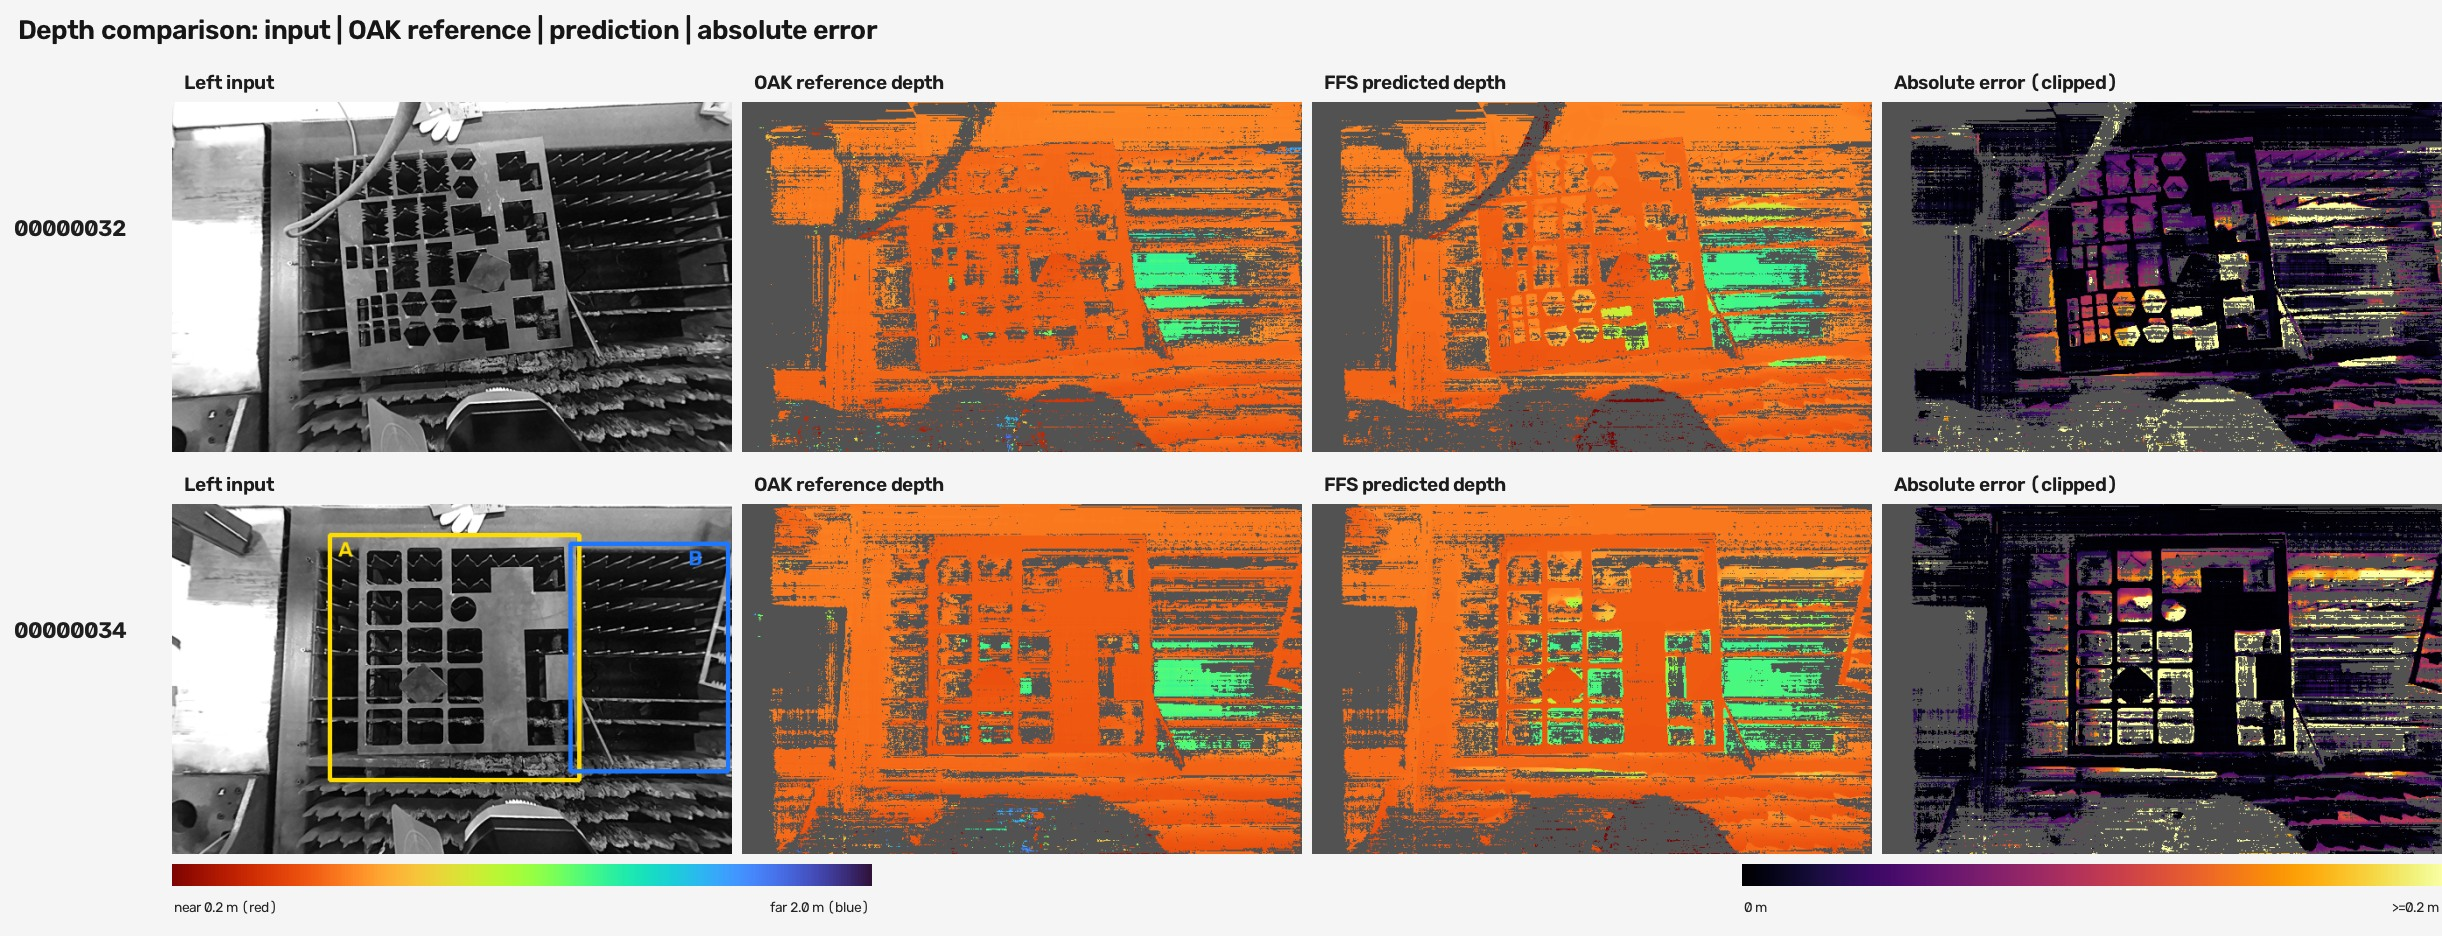

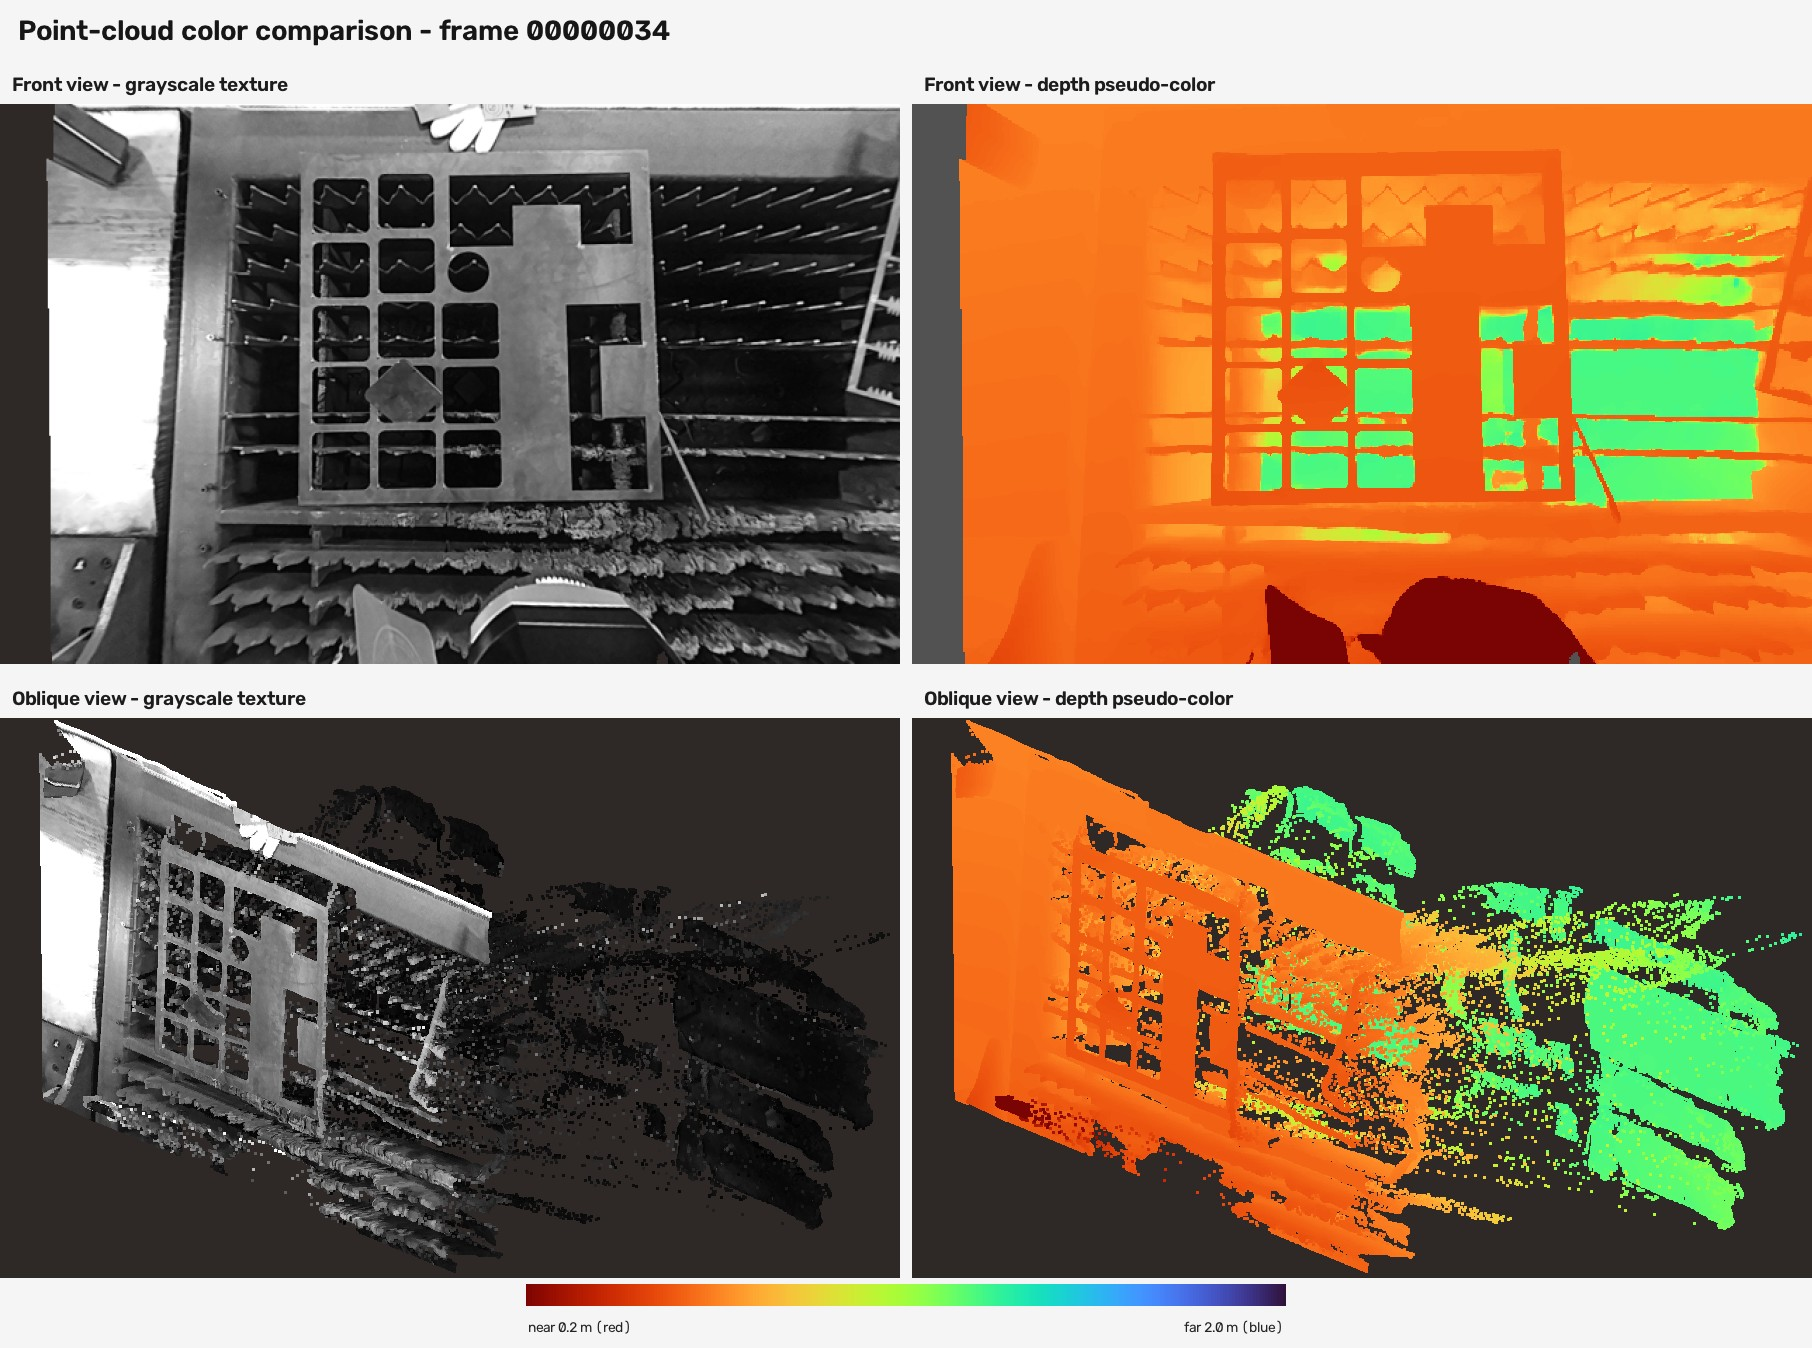

In [6]:
display(Image(filename=str(report_dir / 'qualitative_depth_comparison.jpg'), width=1200))
display(Image(filename=str(report_dir / 'pointcloud_color_comparison.jpg'), width=1000))


## Takeaways

1. **主体平面的一致性较高。** 合并中位绝对误差为约 `4.93 mm`，说明大多数像素误差很小。
2. **少量离群误差主导均值。** MAE 为 `4.51 cm`、RMSE 为 `14.11 cm`；边界腐蚀后 MAE 约减半，孔板、线缆和货架薄边是主要高误差区域。
3. **当前样本集中在 0.5–1.0 m。** 该距离段占主工作范围约 `95.1%`，所以汇总指标主要代表近距离室内场景。
4. **超过 2 m 的 OAK 长尾不适合混入主结论。** 约 `1.0%` 的参考像素超过 2 m，却贡献约 `62.2%` 的全范围绝对误差；参考最大值达到 `64.788 m`。
5. **结论是相对一致性，不是绝对精度认证。** 绝对深度需要卷尺/激光测距平面靶或独立 RGB-D/LiDAR 真值进一步验证。
